## Figure: Agreement and Recource

In [26]:
#%%
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
from functools import partial
import logging

from monoculture.analysis.setup import (
    ACS_TASKS,
    TABLESHIFT_TASKS,
    FIGURES_ROOT_DIR,
)
from monoculture.analysis.utils import (
    load_model_outputs_same_prompt,
    get_size_and_it,
    load_results_overview,
    add_evals_to_df,
    load_data_if_needed,
    filter_results,
    df_to_dict,
)

from monoculture.analysis.plotting import (
    plot_agreement_lineplot,
    plot_recourse_lineplot,
    configure_legend
)


In [28]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

FIGURES_PAPER_DIR = FIGURES_ROOT_DIR / "paper" / "same-prompt"
TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

tasks ('ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


In [29]:
select_by='accuracy' #'balanced_accuracy' #

## Load predictions

In [30]:
num_shots = 0
threshold_fitted = True

df = load_results_overview(
    num_shots=num_shots, threshold_fitted=threshold_fitted, same_prompt=True
)
df = df[df["task"].isin(TASKS)]
df.shape

(349, 15)

In [31]:
try:
    assert set(TASKS).issubset(
        set(df["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df['task'].unique())} "
except AssertionError:
    TASKS = list(df["task"].unique())
    logging.warning(f"Reduced TASKS to available tasks: {TASKS}")

In [32]:
predictions_all = load_model_outputs_same_prompt(
    df, tasks=TASKS, return_risk_scores=False
)

df = add_evals_to_df(df)

ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


## Restrict analysis to models based on performance or true labels?

In [33]:
try:
    data_all
except NameError:
    print("'data_all' not yet defined")
    data_all = load_data_if_needed(data=None, tasks=TASKS)
else:
    print("Already defined, update if needed.")
    data_all = load_data_if_needed(data=data_all, tasks=TASKS)

Already defined, update if needed.


In [34]:
restrict_to_better_const = False
restrict_to_positive_label = False
restrict_to_negative_label = True
restrict_to_top_eps = True
eps = 0.05
restrict_to_topk = False
topk = 10

predictions, data = filter_results(
    predictions=predictions_all.copy(),
    df=df,
    data={t: val for t, val in data_all.items() if t in TASKS},
    tasks=TASKS,
    restrict_to_better_const=restrict_to_better_const,
    restrict_to_positive_label=restrict_to_positive_label,
    restrict_to_negative_label=restrict_to_negative_label,
    restrict_to_top_eps=restrict_to_top_eps,
    restrict_to_topk=restrict_to_topk,
    eps=eps,
    topk=topk,
    acc=select_by
)

ACSIncome (105217, 50)
ACSEmployment (176871, 49)
ACSMobility (45648, 50)
ACSTravelTime (82380, 50)
ACSPublicCoverage (79858, 50)
BRFSS_Diabetes (125299, 50)
BRFSS_Blood_Pressure (40090, 50)
ACSIncome (105217, 23)
ACSEmployment (176871, 7)
ACSMobility (45648, 5)
ACSTravelTime (82380, 10)
ACSPublicCoverage (79858, 24)
BRFSS_Diabetes (125299, 2)
BRFSS_Blood_Pressure (40090, 21)


## Plot

In [35]:
# helpers
def build_filename(name:str):
    parts = [
        f"{name}-{num_shots}-shot",
        f"_selected_by-{select_by}"
        "_tresh_fitted" if threshold_fitted else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        f"_eps{str(eps).replace('.', '_')}" if restrict_to_top_eps else "",
        f"_top{topk}" if restrict_to_topk else "",
    ]
    return "".join(parts)

def plot_agreement_wrapper(ax, predictions: pd.DataFrame, accuracies: dict):
    models_sorted = sorted(predictions.columns, key=get_size_and_it)
    M = len(models_sorted)

    obs_matrix = matrix_pairwise_evals(
        models_sorted, partial(observed_agreement_wrapper, predictions=predictions)
    ).fill_diagonal_(torch.nan)

    exp_matrix = matrix_pairwise_evals(
        models_sorted,
        fun=lambda m1, m2: pairwise_agreement_at_random(accuracies[m1], accuracies[m2]),
    ).fill_diagonal_(torch.nan)

    ax = plot_agreement_lineplot(
        ax,
        obs_matrix[~obs_matrix.isnan()],
        exp_matrix[~exp_matrix.isnan()],
        ylim=(0.45, 1.0),
    )

    print(f"mean agreement: {obs_matrix[~obs_matrix.isnan()].mean():.4f}")
    print(f"mean agreement at random: {exp_matrix[~exp_matrix.isnan()].mean():.4f}")
    return ax


def plot_recourse_wrapper(ax, predictions, baseline_rates, y_true, count_accepted=True, restrict_only_pos_instances=True, num_ticks=3):
    return plot_recourse_lineplot(
        ax,
        predictions=predictions,
        baseline_rates=baseline_rates,
        y_true=y_true,
        restrict_only_pos_instances=restrict_only_pos_instances,
        restrict_only_neg_instances=not(restrict_only_pos_instances),
        count_accepted=count_accepted,
        at_least=False,
        plot_pdf=True,
        xlabel="",
        ylabel="",
        num_ticks=num_ticks,
    )

### Agreement and Recourse in one figure

mean agreement: 0.8948
mean agreement at random: 0.6402


mean agreement: 0.9013
mean agreement at random: 0.6613


mean agreement: 0.9044
mean agreement at random: 0.5942


mean agreement: 0.7573
mean agreement at random: 0.5280


mean agreement: 0.8053
mean agreement at random: 0.5811


mean agreement: 0.7317
mean agreement at random: 0.5235
agreement-recourse-0-shot_selected_by-accuracy_tresh_fitted_neg_instances_eps0_05


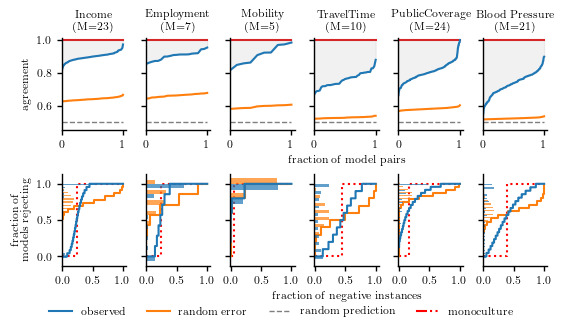

In [36]:
tasks_to_plot = [task for task in TASKS if task != 'BRFSS_Diabetes']

fig_width = plt.rcParams["figure.figsize"][0]
fig_height = plt.rcParams["figure.figsize"][1]

fig, axs = plt.subplots(
    2,
    len(tasks_to_plot),
    figsize=(fig_width, fig_height),
    sharey="row",
    constrained_layout=True,
)

recourse_observed = {}
recourse_at_random = {}

for i, task in enumerate(tasks_to_plot):
    M = len(predictions[task].columns)
    mask = (df["task"] == task) & (df["model"].isin(predictions[task].columns))

    # agreement
    acc_dict = df_to_dict(df[mask][["model", "accuracy"]])
    axs[0,i] = plot_agreement_wrapper(
        axs[0,i], predictions=predictions[task], accuracies=acc_dict
    )

    # recourse
    tp_rates = list(1.0 - df[mask]["fnr"].values)
    tn_rates = list(1.0 - df[mask]["fpr"].values)
    axs[1,i], observed, at_random = plot_recourse_wrapper(
        axs[1,i],
        predictions=predictions[task],
        baseline_rates=tn_rates,
        y_true=data[task][1],
        count_accepted=False,
        restrict_only_pos_instances=False # --> neg = True
    )
    recourse_observed[task] = observed
    recourse_at_random[task] = at_random

    axs[0, i].set_title(
                f"{task.replace('ACS', '').replace('BRFSS', '').replace('_', ' ')}\n(M={M})"
            )
    
axs[0, 0].set_ylabel("agreement")
axs[0, len(tasks_to_plot) // 2].set_xlabel("fraction of model pairs")

axs[1, 0].set_ylabel("fraction of\n models rejecting")
axs[1, len(tasks_to_plot) // 2].set_xlabel("fraction of negative instances")
configure_legend(fig, axs, offset= 0.18)

file_name = build_filename(name="agreement-recourse")
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_PAPER_DIR / f"{file_name}{ending}")
print(file_name)

plt.show()

In [37]:
import numpy as np
output = f"{'task':20} & M & \tno recourse & substantial recourse & full recourse\\\\"

for task in recourse_observed.keys():
    M = len(predictions[task].columns)
    rec = recourse_observed[task]
    rec_frac_individuals = rec[:, 1]
    max_frac_no_rec = rec[rec[:,1] == 0.0][-1][0] if len(rec[rec[:,1] == 0.0])>0 else 0.0
    max_frac_limited_rec = rec[rec[:,1] <= .5][-1][0] if len(rec[rec[:,1] <= .5])>0 else 0.0
    min_frac_no_rec = rec[rec[:,1] == 1.0][0][0] if len(rec[np.isclose(rec[:,1], 1.0)])>0 else 1.0
    output += (f"\n{task.replace('_', ' '):20} &\t {M} &\t{max_frac_no_rec:.2f}"
          f"&\t{1. - max_frac_limited_rec:.2f}"
          f"&\t{1. - min_frac_no_rec:.2f}\\\\")
    
print(output)
with open(FIGURES_PAPER_DIR/ (build_filename('recourse_table')+'.txt'), "w") as file:
    file.write(output)

task                 & M & 	no recourse & substantial recourse & full recourse\\
ACSIncome            &	 23 &	0.08&	0.76&	0.55\\
ACSEmployment        &	 7 &	0.14&	0.77&	0.62\\
ACSMobility          &	 5 &	0.00&	1.00&	0.77\\
ACSTravelTime        &	 10 &	0.13&	0.53&	0.23\\
ACSPublicCoverage    &	 24 &	0.00&	0.90&	0.32\\
BRFSS Blood Pressure &	 21 &	0.05&	0.65&	0.14\\


### Only Agreement

ACSIncome
mean agreement: 0.8948
mean agreement at random: 0.6402
ACSEmployment
mean agreement: 0.9013
mean agreement at random: 0.6613
ACSMobility
mean agreement: 0.9044
mean agreement at random: 0.5942
ACSTravelTime
mean agreement: 0.7573
mean agreement at random: 0.5280
ACSPublicCoverage
mean agreement: 0.8053
mean agreement at random: 0.5811
BRFSS_Blood_Pressure
mean agreement: 0.7317
mean agreement at random: 0.5235


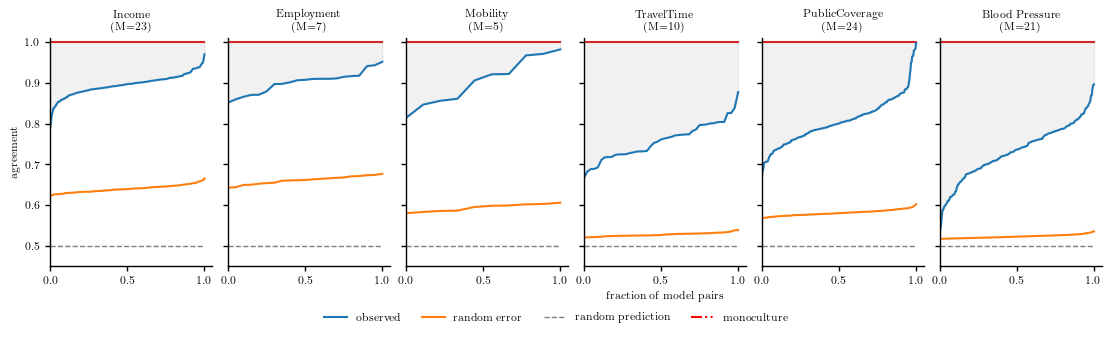

In [38]:
tasks_to_plot = [task for task in TASKS if task != 'BRFSS_Diabetes'] 

fig_width = 2*plt.rcParams["figure.figsize"][0]
fig_height = plt.rcParams["figure.figsize"][1]

fig, axs = plt.subplots(
    1,
    len(tasks_to_plot),
    figsize=(fig_width, fig_height),
    sharey="row",
    constrained_layout=True,
)

for i, task in enumerate(tasks_to_plot):
    print(task)
    M = len(predictions[task].columns)
    # agreement
    mask = (df["task"] == task) & (df["model"].isin(predictions[task].columns))
    acc_dict = df_to_dict(df[mask][["model", "accuracy"]])
    axs[i] = plot_agreement_wrapper(
        axs[i], predictions=predictions[task], accuracies=acc_dict
    )

    axs[i].set_title(
                f"{task.replace('ACS', '').replace('BRFSS', '').replace('_', ' ')}\n(M={M})"
            )
    
axs[0].set_ylabel("agreement")
axs[len(tasks_to_plot) // 2].set_xlabel("fraction of model pairs")

configure_legend(fig, axs, offset= 0.2)

file_name = build_filename(name="agreement")

plt.show()

### Only Recourse

In [39]:
tasks_to_plot = [task for task in TASKS if task != 'BRFSS_Diabetes'] 

fig_width = 2*plt.rcParams["figure.figsize"][0]
fig_height = plt.rcParams["figure.figsize"][1]

fig, axs = plt.subplots(
    1,
    len(tasks_to_plot),
    figsize=(fig_width, fig_height),
    sharey="row",
    constrained_layout=True,
)

recourse_observed = {}
recourse_at_random = {}
for i, ax in enumerate(axs.flat):
    task = tasks_to_plot[i]
    print(task)
    M = len(predictions[task].columns)
    mask = (df["task"] == task) & (df["model"].isin(predictions[task].columns))

    #recourse
    tp_rates = list(1.0 - df[mask]["fnr"].values)
    ax, observed, at_random = plot_recourse_wrapper(
        ax,
        predictions=predictions[task],
        baseline_rates=tp_rates,
        y_true=data[task][1],
    )
    recourse_observed[task] = observed
    recourse_at_random[task] = at_random

    ax.set_title(
                f"{task.replace('ACS', '').replace('BRFSS', '').replace('_', ' ')}\n(M={M})"
            )
    
axs[0].set_ylabel("agreement")
axs[len(tasks_to_plot) // 2].set_xlabel("fraction of model pairs")

configure_legend(fig, axs, offset= 0.25)

file_name = build_filename(name="recourse")

plt.show()

ACSIncome


ValueError: operands could not be broadcast together with shapes (0,) (105217,) 

In [ ]:
print(f"{num_shots}-shot")
print(f"{'model':15} & M &\tno recourse & substantial recourse& full recourse\\\\")
# (fraction_individuals, fraction_models_observed)

for task in list(recourse_observed.keys()):
    M = predictions[task].shape[1]
    rec = recourse_observed[task]
    frac_models = rec[:,1]
    frac_ind = rec[:,0]
    max_frac_no_rec = frac_ind[frac_models == 0.0][-1] if len(rec[frac_models == 0.])>0 else 0.0
    max_frac_limited_rec = frac_ind[frac_models <= .5][-1] if len(rec[frac_models <= .5])>0 else 0.0
    min_frac_substantial_rec = 1. - frac_ind[frac_models > 0.5][0] if len(rec[frac_models > .5])>0 else 0.0
    min_frac_no_rec = 1. - frac_ind[frac_models == 1.0][0] if len(rec[np.isclose(frac_models, 1.)])>0 else 0.0
    print(f"{task.replace('_', ' '):20} & {M} &\t{max_frac_no_rec:.2f}"
          f"&\t{min_frac_substantial_rec:.2f}"
          f"&\t{min_frac_no_rec:.2f}\\\\")

0-shot
model           & M &	no recourse & substantial recourse& full recourse\\
ACSIncome            & 23 &	0.08&	0.80&	0.53\\
ACSEmployment        & 7 &	0.06&	0.83&	0.65\\
ACSMobility          & 5 &	0.68&	0.00&	0.00\\
ACSTravelTime        & 10 &	0.05&	0.72&	0.32\\
ACSPublicCoverage    & 24 &	0.12&	0.37&	0.00\\
BRFSS Blood Pressure & 21 &	0.04&	0.61&	0.17\\
